# Ноутбук 03. Розмітка шаблонів на рівні template + діагностична кластеризація

Цей ноутбук реалізує розмітку $\ell : T \to \{0, 1\}$ безпосередньо на рівні **шаблонів** (амендмент архітектури — див. розділи 2.1–2.3 тези). Попередня cluster-level схема з $\pi(c)$ та порогом 0.5 на кластері виявилась оперативно непридатною (KMeans дав $k=3$, Silhouette = 0.2527, ~77 % записів отримали мітку 1 — це наслідок анізотропії BERT, розділ 1.7).

Нова логіка:

* KMeans + Silhouette + t-SNE/UMAP — **лише діагностика геометрії**, ніколи не джерело міток.
* $\pi(t) = \frac{|\{m : t(m) = t,\ \mathrm{Level}(m) \in \{\mathrm{WARN}, \mathrm{ERROR}\}\}|}{|\{m : t(m) = t\}|}$ — частка «позитивних» записів для шаблону $t$ (formula `eq:level_pi`, перенесена на рівень шаблону).
* $\ell^{(0)}(t) = 1$ якщо $\pi(t) \geq 0.5$, інакше 0 (formula `eq:l_initial`, threshold $\tau = 0.5$).
* $\ell(t) = \mathrm{corrections}.\mathrm{get}(t, \ell^{(0)}(t))$ — фінальна мітка після ручного коригування експертом.

Вихідні артефакти (`template_to_binary_label.json`, `record_to_binary_label.npy`) — це навчальний сигнал для ноутбука 04 (класифікація на парах `(template_vector, final_label)`).


In [1]:
from __future__ import annotations

import json
import logging
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
EMBEDDINGS_DIR = DATA_PROCESSED / 'embeddings'
CLUSTERS_DIR = DATA_PROCESSED / 'clusters'
CLUSTERS_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)s — %(message)s',
    force=True,
)
# Drain logs one INFO line per parsed log record; with 74380 lines this would
# swamp the notebook. Keep our own logger at INFO but silence the noisy ones.
logging.getLogger('drain3').setLevel(logging.WARNING)
logging.getLogger('src.drain.parser').setLevel(logging.WARNING)
logging.getLogger('numba').setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

np.random.seed(42)

from src.clustering.kmeans_pipeline import ClusteringPipeline
from src.clustering.labeling import (
    apply_template_corrections,
    compute_template_stats,
)
from src.drain.parser import DrainParser
from src.io.persistence import load_json, load_numpy, save_json, save_numpy
from src.preprocessing.regex_normalizer import RegexNormalizer

print(f'numpy = {np.__version__}')
print(f'pandas = {pd.__version__}')


/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy = 2.4.4
pandas = 3.0.2


## 1. Завантаження ембедингів з ноутбука 02

Зчитуємо 768-вимірні BERT-вектори шаблонів та супровідне зіставлення `row_index -> template_id`, які зберіг ноутбук 02.


In [2]:
embeddings = load_numpy(EMBEDDINGS_DIR / 'zookeeper_full_embeddings.npy')
id_mapping: list[dict] = load_json(EMBEDDINGS_DIR / 'zookeeper_full_id_mapping.json')

assert embeddings.shape == (77, 768), f'unexpected shape: {embeddings.shape}'
assert embeddings.dtype == np.float32, f'unexpected dtype: {embeddings.dtype}'
assert len(id_mapping) == 77

print(f'embeddings shape = {embeddings.shape}, dtype = {embeddings.dtype}')
print(f'id_mapping entries = {len(id_mapping)}')
print(f'first template (row_index=0, template_id={id_mapping[0]["template_id"]}):')
print(f'  {id_mapping[0]["template"][:80]}')


embeddings shape = (77, 768), dtype = float32
id_mapping entries = 77
first template (row_index=0, template_id=20):
  Received connection request /<IP>


## 2. L2-нормалізація: підготовка до діагностичної KMeans

Попередньо натреновані BERT-вектори анізотропні (займають вузький конус у $\mathbb{R}^{768}$, див. розділ 1.7 тези та Ethayarajh 2019). Тому перед KMeans ми нормуємо кожен вектор до одиничної довжини — це переводить евклідову відстань на одиничну гіперсферу, де вона монотонно пов'язана з косинусною відстанню (сферичний k-means). Без цього кроку плоский KMeans на сирих BERT-векторах поводиться некоректно.

⚠️ KMeans тут використовується **виключно як діагностика геометрії** (Silhouette + t-SNE/UMAP). Кластерні мітки **не** використовуються для бінарної розмітки — розмітка тепер реалізується безпосередньо на рівні шаблонів (див. §8).


In [3]:
pipeline = ClusteringPipeline(k_values=[3, 5, 7, 10, 12, 15, 20], random_state=42)
embeddings_norm = pipeline.get_l2_normalized(embeddings)

pre_norms = np.linalg.norm(embeddings, axis=1)
post_norms = np.linalg.norm(embeddings_norm, axis=1)

print(f'norm before L2 — min={pre_norms.min():.3f}, max={pre_norms.max():.3f}, mean={pre_norms.mean():.3f}')
print(f'norm after  L2 — min={post_norms.min():.6f}, max={post_norms.max():.6f}, mean={post_norms.mean():.6f}')

assert embeddings_norm.shape == embeddings.shape
assert np.allclose(post_norms, 1.0, atol=1e-5), 'L2 normalization did not produce unit vectors'


norm before L2 — min=13.379, max=15.821, mean=14.106
norm after  L2 — min=1.000000, max=1.000000, mean=1.000000


## 3. Діагностичний підбір $k$ за Silhouette

Перебираємо сітку $k \in \{3, 5, 7, 10, 12, 15, 20\}$, для кожного значення тренуємо KMeans та обчислюємо Silhouette з косинусною метрикою на L2-нормованих векторах. Найкраще $k$ обирається за максимумом Silhouette — це лише ілюстрація того, як шаблони групуються в семантичному просторі. Отримані `cluster_id` далі використовуємо **тільки** для розфарбовування t-SNE/UMAP (§4–§5).


2026-05-19 22:22:58,249 INFO src.clustering.kmeans_pipeline — k=3 silhouette=0.2527


2026-05-19 22:22:58,257 INFO src.clustering.kmeans_pipeline — k=5 silhouette=0.1837


2026-05-19 22:22:58,267 INFO src.clustering.kmeans_pipeline — k=7 silhouette=0.1707


2026-05-19 22:22:58,278 INFO src.clustering.kmeans_pipeline — k=10 silhouette=0.1576


2026-05-19 22:22:58,291 INFO src.clustering.kmeans_pipeline — k=12 silhouette=0.1653


2026-05-19 22:22:58,308 INFO src.clustering.kmeans_pipeline — k=15 silhouette=0.1613


2026-05-19 22:22:58,328 INFO src.clustering.kmeans_pipeline — k=20 silhouette=0.1895


Silhouette scores:
  k= 3: 0.2527 <-- best
  k= 5: 0.1837
  k= 7: 0.1707
  k=10: 0.1576
  k=12: 0.1653
  k=15: 0.1613
  k=20: 0.1895


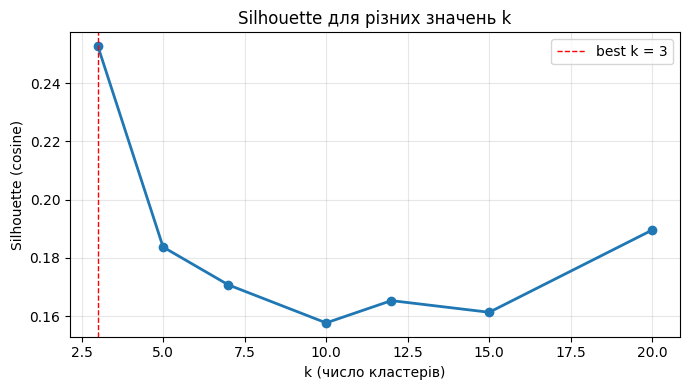

In [4]:
scores = pipeline.fit_and_score(embeddings)
best_k_preview = max(scores, key=lambda k: (scores[k], -k))

print('Silhouette scores:')
for k_val, s in scores.items():
    marker = ' <-- best' if k_val == best_k_preview else ''
    print(f'  k={k_val:>2}: {s:.4f}{marker}')

ks = list(scores.keys())
vals = [scores[k] for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, vals, marker='o', linewidth=2)
plt.axvline(best_k_preview, color='red', linestyle='--', linewidth=1, label=f'best k = {best_k_preview}')
plt.xlabel('k (число кластерів)')
plt.ylabel('Silhouette (cosine)')
plt.title('Silhouette для різних значень k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


2026-05-19 22:22:58,408 INFO src.clustering.kmeans_pipeline — k=3 silhouette=0.2527


2026-05-19 22:22:58,416 INFO src.clustering.kmeans_pipeline — k=5 silhouette=0.1837


2026-05-19 22:22:58,425 INFO src.clustering.kmeans_pipeline — k=7 silhouette=0.1707


2026-05-19 22:22:58,436 INFO src.clustering.kmeans_pipeline — k=10 silhouette=0.1576


2026-05-19 22:22:58,449 INFO src.clustering.kmeans_pipeline — k=12 silhouette=0.1653


2026-05-19 22:22:58,464 INFO src.clustering.kmeans_pipeline — k=15 silhouette=0.1613


2026-05-19 22:22:58,483 INFO src.clustering.kmeans_pipeline — k=20 silhouette=0.1895


2026-05-19 22:22:58,488 INFO src.clustering.kmeans_pipeline — best k=3 silhouette=0.2527


optimal k = 3
silhouette at best k = 0.2527
cluster_labels shape = (77,)

cluster size distribution (3 clusters):
  cluster  0: 31 templates
  cluster  1: 29 templates
  cluster  2: 17 templates


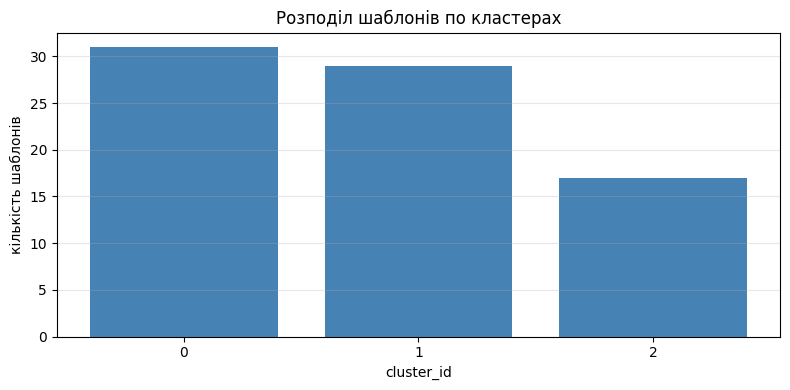

In [5]:
best_k, kmeans_model, cluster_labels = pipeline.fit_best(embeddings)

print(f'optimal k = {best_k}')
print(f'silhouette at best k = {scores[best_k]:.4f}')
print(f'cluster_labels shape = {cluster_labels.shape}')

unique, counts = np.unique(cluster_labels, return_counts=True)
print(f'\ncluster size distribution ({len(unique)} clusters):')
for c, n in zip(unique, counts):
    print(f'  cluster {int(c):>2}: {int(n)} templates')

plt.figure(figsize=(8, 4))
plt.bar([int(c) for c in unique], [int(n) for n in counts], color='steelblue')
plt.xlabel('cluster_id')
plt.ylabel('кількість шаблонів')
plt.title('Розподіл шаблонів по кластерах')
plt.xticks(list(unique))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Діагностика t-SNE (розфарбовка за `cluster_id`)

t-SNE проєктує 768-вимірні вектори у 2D, зберігаючи переважно локальну структуру. Параметр `perplexity` зменшено з типового 30 до 10, оскільки $N=77$ — це малий датасет, і високе значення `perplexity` згладило б структуру кластерів. Цей рисунок показує лише геометрію KMeans-кластерів; **другий рисунок з тими самими координатами, але розфарбованими бінарною міткою**, наведено у §10 для перевірки роздільності класів після template-level розмітки.


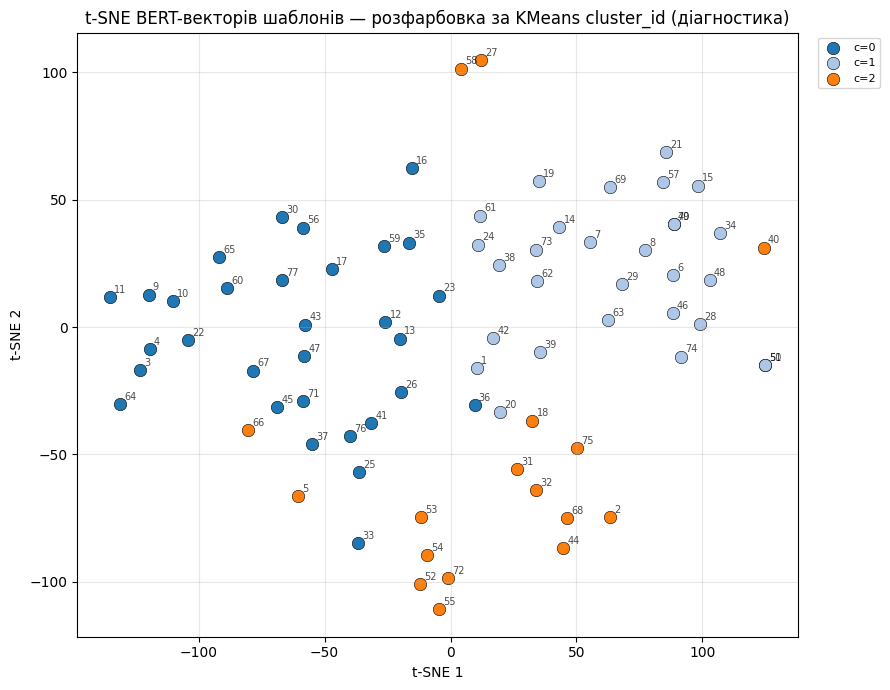

saved: /Users/roman/Personal/dyploma/data/processed/clusters/tsne_by_cluster.png


In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42,
    init='pca',
    learning_rate='auto',
)
tsne_proj = tsne.fit_transform(embeddings_norm)  # shape (77, 2); kept in scope for re-plot in §10

palette = sns.color_palette('tab20', n_colors=best_k)

plt.figure(figsize=(9, 7))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(
        tsne_proj[mask, 0],
        tsne_proj[mask, 1],
        s=80,
        color=palette[c],
        label=f'c={c}',
        edgecolors='black',
        linewidths=0.4,
    )

for row_index, (x, y) in enumerate(tsne_proj):
    tid = id_mapping[row_index]['template_id']
    plt.annotate(str(tid), (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

plt.title('t-SNE BERT-векторів шаблонів — розфарбовка за KMeans cluster_id (діагностика)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / 'tsne_by_cluster.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved: {CLUSTERS_DIR / "tsne_by_cluster.png"}')


## 5. Діагностика UMAP (розфарбовка за `cluster_id`)

UMAP зберігає одночасно локальну й глобальну структуру; параметр `n_neighbors` зменшено з типового 15 до 8 з тих самих міркувань, що й `perplexity` для t-SNE. Рисунок, розфарбований бінарною міткою, з'явиться у §10 поряд із цим.


/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


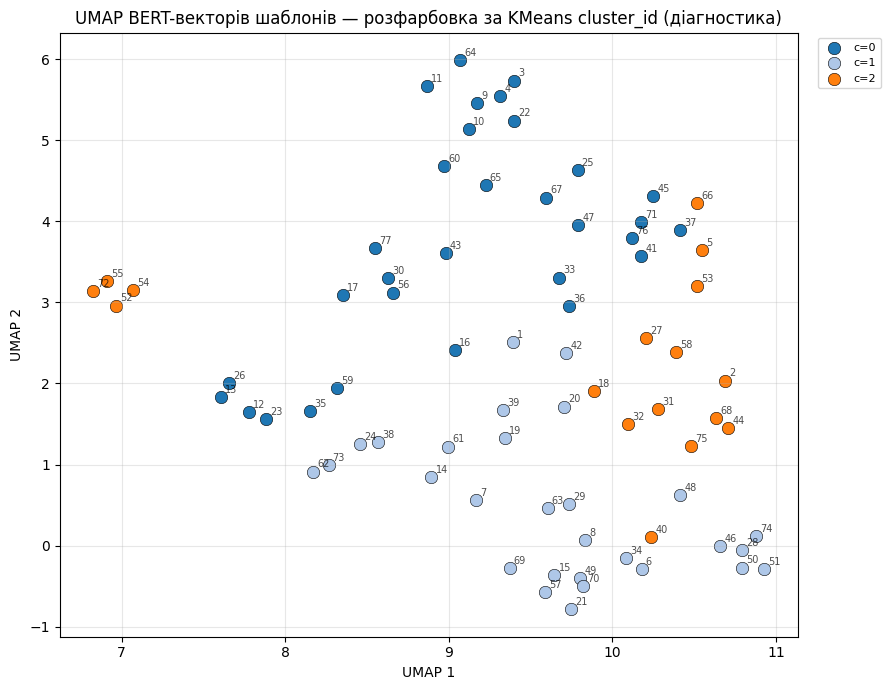

saved: /Users/roman/Personal/dyploma/data/processed/clusters/umap_by_cluster.png


In [7]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=8,
    min_dist=0.1,
    random_state=42,
    metric='cosine',
)
umap_proj = reducer.fit_transform(embeddings_norm)  # shape (77, 2); kept in scope for re-plot in §10

plt.figure(figsize=(9, 7))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(
        umap_proj[mask, 0],
        umap_proj[mask, 1],
        s=80,
        color=palette[c],
        label=f'c={c}',
        edgecolors='black',
        linewidths=0.4,
    )

for row_index, (x, y) in enumerate(umap_proj):
    tid = id_mapping[row_index]['template_id']
    plt.annotate(str(tid), (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

plt.title('UMAP BERT-векторів шаблонів — розфарбовка за KMeans cluster_id (діагностика)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / 'umap_by_cluster.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved: {CLUSTERS_DIR / "umap_by_cluster.png"}')


## 6. Витягування Level для кожного запису

Повний `Zookeeper.log` не супроводжується структурованим CSV з полем `Level` (на відміну від 2k-підвибірки) — див. розділ 2.4 тези. Тому витягуємо `Level` безпосередньо з кожного сирого рядка регулярним виразом `RegexNormalizer.extract_level`.


In [8]:
normalizer = RegexNormalizer()

raw_path = DATA_RAW / 'Zookeeper.log'
record_levels: list[str | None] = []
with raw_path.open('r', encoding='utf-8', errors='replace') as f:
    for line in tqdm(f, desc='extract Level'):
        record_levels.append(normalizer.extract_level(line))

level_counter = Counter(record_levels)
print(f'total records read: {len(record_levels)}')
print('Level distribution:')
for lvl, n in sorted(level_counter.items(), key=lambda kv: -kv[1]):
    print(f'  {str(lvl):<6}: {n}')

assert len(record_levels) == 74380, f'expected 74380 lines, got {len(record_levels)}'


extract Level: 0it [00:00, ?it/s]

extract Level: 74380it [00:00, 1839448.66it/s]

total records read: 74380
Level distribution:
  WARN  : 48507
  INFO  : 25256
  ERROR : 617


## 7. Мапування записів до шаблонів

Для обчислення $\pi(c)$ за формулою `eq:level_pi` потрібен `template_id` кожного з 74380 записів. Ноутбук 01 не зберігав цю інформацію поряд із самим списком шаблонів, але Drain — детермінований при тих самих вхідних даних і конфігурації, тому повторно проганяємо нормалізовані рядки через `DrainParser` й читаємо `template_id` з результатів.


In [9]:
normalized_path = DATA_PROCESSED / 'zookeeper_full_normalized.txt'
with normalized_path.open('r', encoding='utf-8') as f:
    normalized_lines = [line.rstrip('\n') for line in f]

assert len(normalized_lines) == 74380, f'expected 74380 normalized lines, got {len(normalized_lines)}'

parser = DrainParser(similarity_threshold=0.4, depth=4, max_children=100)
results = parser.parse_stream(normalized_lines)
record_template_ids = [r.template_id for r in results]

n_unique = len(set(record_template_ids))
print(f'records parsed: {len(record_template_ids)}')
print(f'unique template_ids: {n_unique}')

if n_unique != 77:
    raise RuntimeError(
        f'Очікувалося 77 унікальних template_id, але отримано {n_unique}. '
        'Це означає, що Drain повернув іншу розбивку, ніж в ноутбуці 01. '
        'Перевірте вхідний файл та параметри DrainParser.'
    )


drain parse:   0%|          | 0/74380 [00:00<?, ?it/s]

drain parse:  24%|██▍       | 17669/74380 [00:00<00:00, 175037.57it/s]

drain parse:  47%|████▋     | 35173/74380 [00:00<00:00, 101643.92it/s]

drain parse:  83%|████████▎ | 61671/74380 [00:00<00:00, 155068.24it/s]

drain parse: 100%|██████████| 74380/74380 [00:00<00:00, 157229.30it/s]

records parsed: 74380
unique template_ids: 77


## 8. Етап 1 процедури розмітки — rule-based перший прохід на рівні шаблонів

Реалізуємо формули `eq:level_pi` та `eq:l_initial` з розділу 2.3 тези в **template-level** формі. Для кожного шаблону $t$ обчислюється $\pi(t)$ — частка записів цього шаблону з `Level` $\in$ {WARN, ERROR}. Якщо $\pi(t) \geq 0{,}5$, шаблону присвоюється попередня мітка 1 (інформативний), інакше 0. Записи з `Level = None` (рядки, які регулярний вираз не розпарсив) входять у знаменник, але не в чисельник. Чиста функція `compute_template_stats` з `src/clustering/labeling.py` виконує цей крок.

Друкуємо повну таблицю усіх 77 шаблонів, відсортовану за support (спадання) — саме її експерт переглядає в §9 для рішень про коригування.


In [10]:
template_stats = compute_template_stats(
    record_template_ids=record_template_ids,
    record_levels=record_levels,
    id_mapping=id_mapping,
    positive_levels={'WARN', 'ERROR'},
    threshold=0.5,
)
assert len(template_stats) == 77

# Per-template review table sorted by support desc. Each row gives the expert
# enough signal to decide whether the rule_label is plausible.
review_rows = [
    {
        'template_id': r['template_id'],
        'support': r['support'],
        'pi': round(r['pi'], 3),
        'rule_label': r['rule_label'],
        'template': r['template'][:80],
    }
    for r in template_stats
]
review_df = pd.DataFrame(review_rows).sort_values('support', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 200)
print(f'rule-based labels for {len(template_stats)} templates (sorted by support desc):')
print(review_df.to_string(index=False))

rule_counts = Counter(r['rule_label'] for r in template_stats)
print(f'\nrule_label distribution across templates: 0 = {rule_counts[0]}, 1 = {rule_counts[1]}')


rule-based labels for 77 templates (sorted by support desc):
 template_id  support  pi  rule_label                                                                         template
          20    10429 0.0           0                                                Received connection request /<IP>
          31    10390 1.0           1                                                          Interrupting SendWorker
          33    10390 1.0           1                                                       Send worker leaving thread
          30    10388 1.0           1                           Connection broken for id <NUM>, my id = <NUM>, error =
          32    10386 1.0           1                                   Interrupted while waiting for message on queue
          18     2584 1.0           1                           Cannot open channel to <NUM> at election address /<IP>
          36     2020 0.0           0                                            Accepted socket connectio

## 9. Етап 2 процедури розмітки — експертне коригування на рівні шаблонів

Після rule-based проходу частина шаблонів може мати помилкову мітку — наприклад, шаблон про штатний lifecycle потоків з рівнем WARN (шум, не інформативно) або, навпаки, критичний шаблон, що пишеться рівнем INFO. Експерт переглядає таблицю з §8 та вписує необхідні коригування у два словники нижче, обидва ключовані `template_id`:

* `corrections: dict[int, int]` — нова бінарна мітка для конкретного шаблону.
* `correction_reasons: dict[int, str]` — українське обґрунтування рішення, яке потрапить у JSON-експорт як поле `reason`.

Inline-коментар (`# ...`) у `corrections` дублює `correction_reasons` для документації безпосередньо у коді. За замовчуванням обидва словники порожні — щоб увімкнути коригування, заповніть їх після інспекції §8 і перезапустіть §9–§12.


In [11]:
# Експертні коригування міток шаблонів. Ключ — template_id, значення — нова мітка (0 або 1).
# Кожен запис повинен супроводжуватись inline-коментарем українською (обґрунтування)
# та дублюватись у correction_reasons нижче.
corrections: dict[int, int] = {
    # 31: 0,  # SendWorker lifecycle — штатний шум потоків, не критично
}

correction_reasons: dict[int, str] = {
    # 31: "SendWorker lifecycle — штатний шум потоків, не критично",
}

# Sanity: every override must have a paired Ukrainian reason for the JSON export.
missing_reason = sorted(set(corrections) - set(correction_reasons))
if missing_reason:
    print(f'WARNING: corrections without correction_reasons (reason field will be ""): {missing_reason}')

print(f'Defined {len(corrections)} corrections (empty by default — fill in manually).')


Defined 0 corrections (empty by default — fill in manually).


In [12]:
labeled = apply_template_corrections(template_stats, corrections, correction_reasons)
assert len(labeled) == 77

# tid_to_final: template_id -> final binary label (after corrections).
tid_to_final: dict[int, int] = {r['template_id']: r['final_label'] for r in labeled}

# Project per-record assignments through tid_to_final to get the per-record label.
# record_to_binary: shape (74380,), dtype int8 — used as the supervised signal in notebook 04.
record_to_binary = np.array([tid_to_final[t] for t in record_template_ids], dtype=np.int8)

n_changed = sum(1 for r in labeled if r['corrected'] and r['final_label'] != r['rule_label'])
final_counts = Counter(r['final_label'] for r in labeled)

print(f'templates changed by expert correction: {n_changed}')
print(f'final label distribution (templates): 0 = {final_counts[0]}, 1 = {final_counts[1]}')
print(f'record_to_binary shape = {record_to_binary.shape}, dtype = {record_to_binary.dtype}')


templates changed by expert correction: 0
final label distribution (templates): 0 = 59, 1 = 18
record_to_binary shape = (74380,), dtype = int8


## 10. Перевірка роздільності класів — t-SNE/UMAP за бінарною міткою

Ті самі координати t-SNE і UMAP з §4–§5, але тепер кожен шаблон розфарбовано за **фінальною бінарною міткою** $\ell(t) \in \{0, 1\}$. Якщо template-level розмітка узгоджена з геометрією BERT, ми очікуємо побачити приблизне просторове розділення двох класів навіть без явної supervised сигналізації. Це не математичний доказ, а sanity-перевірка перед навчанням класифікаторів у ноутбуці 04.


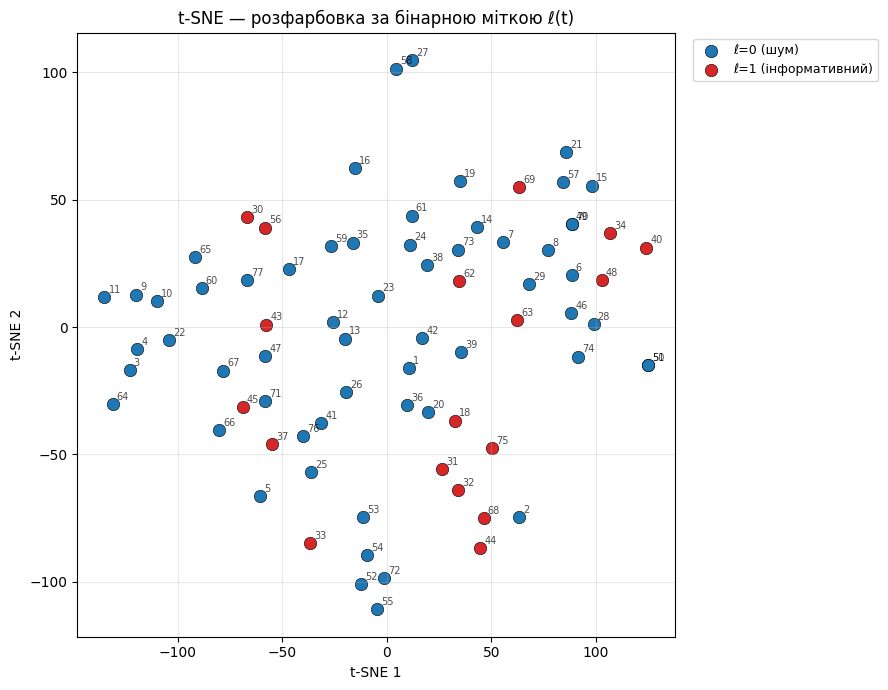

saved: /Users/roman/Personal/dyploma/data/processed/clusters/tsne_by_label.png


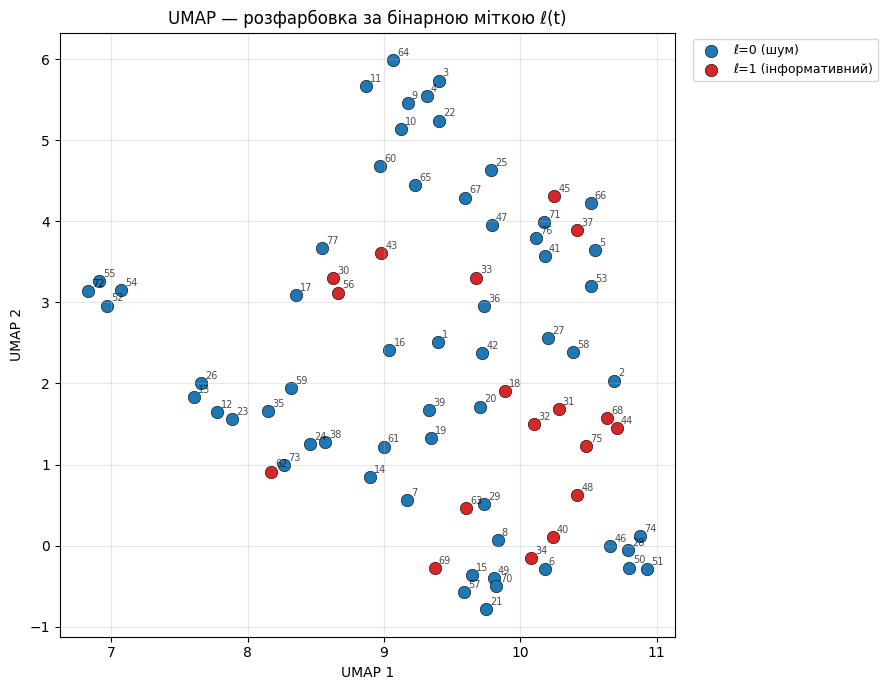

saved: /Users/roman/Personal/dyploma/data/processed/clusters/umap_by_label.png


In [13]:
# label_per_row[i] = final binary label for the template at row_index=i in id_mapping
# Shape (77,), values in {0, 1}.
label_per_row = np.array(
    [tid_to_final[m['template_id']] for m in id_mapping],
    dtype=np.int8,
)

label_palette = {0: '#1f77b4', 1: '#d62728'}  # blue = неінформативний, red = інформативний
label_names = {0: 'ℓ=0 (шум)', 1: 'ℓ=1 (інформативний)'}


def _scatter_by_label(proj: np.ndarray, projection_name: str, savepath: Path) -> None:
    plt.figure(figsize=(9, 7))
    for lbl in (0, 1):
        mask = label_per_row == lbl
        plt.scatter(
            proj[mask, 0],
            proj[mask, 1],
            s=80,
            color=label_palette[lbl],
            label=label_names[lbl],
            edgecolors='black',
            linewidths=0.4,
        )
    for row_index, (x, y) in enumerate(proj):
        tid = id_mapping[row_index]['template_id']
        plt.annotate(str(tid), (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    plt.title(f'{projection_name} — розфарбовка за бінарною міткою ℓ(t)')
    plt.xlabel(f'{projection_name} 1')
    plt.ylabel(f'{projection_name} 2')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'saved: {savepath}')


_scatter_by_label(tsne_proj, 't-SNE', CLUSTERS_DIR / 'tsne_by_label.png')
_scatter_by_label(umap_proj, 'UMAP', CLUSTERS_DIR / 'umap_by_label.png')


## 11. Експорт результатів

Зберігаємо у `data/processed/clusters/`:

* `template_to_binary_label.json` — список з 77 об'єктів, ключі: `template_id`, `template`, `support`, `pi`, `level_counts`, `rule_label`, `final_label`, `corrected`, `reason`. Сортування — за `template_id` (для стабільних diff-ів).
* `record_to_binary_label.npy` — масив `int8` форми `(74380,)`, фінальна бінарна мітка кожного запису.
* `record_to_cluster.npy` — масив `int32` форми `(74380,)`, **діагностичний** (KMeans `cluster_id` для кожного запису).
* `cluster_summary.csv` — діагностична таблиця по кластерах (без колонок міток).
* `cluster_labels_per_template.json` — діагностичне зіставлення `template_id → cluster_id`.

Застарілий артефакт `binary_labels_per_cluster.json` (cluster-level мітки) видаляється на диску, щоб не накопичувалось сміття. Ноутбук 04 буде читати лише `template_to_binary_label.json` та `record_to_binary_label.npy`.


In [14]:
template_to_binary_path = CLUSTERS_DIR / 'template_to_binary_label.json'
record_to_binary_path = CLUSTERS_DIR / 'record_to_binary_label.npy'
record_to_cluster_path = CLUSTERS_DIR / 'record_to_cluster.npy'
cluster_per_template_path = CLUSTERS_DIR / 'cluster_labels_per_template.json'
cluster_summary_path = CLUSTERS_DIR / 'cluster_summary.csv'
legacy_binary_per_cluster_path = CLUSTERS_DIR / 'binary_labels_per_cluster.json'

# Drop the deprecated cluster-level label file if it survives from a previous run.
legacy_binary_per_cluster_path.unlink(missing_ok=True)

# 1) template_to_binary_label.json — sorted by template_id for stable diffs.
template_to_binary_rows = sorted(labeled, key=lambda r: r['template_id'])
save_json(template_to_binary_rows, template_to_binary_path)

# 2) record_to_binary_label.npy — already computed in §9.
save_numpy(record_to_binary, record_to_binary_path)

# 3) record_to_cluster.npy — diagnostic per-record KMeans cluster id.
#    tid_to_row maps template_id -> row_index in id_mapping, and cluster_labels[row_index]
#    is the per-template cluster assignment.
tid_to_row: dict[int, int] = {entry['template_id']: entry['row_index'] for entry in id_mapping}
record_to_cluster = np.array(
    [int(cluster_labels[tid_to_row[t]]) for t in record_template_ids],
    dtype=np.int32,
)
save_numpy(record_to_cluster, record_to_cluster_path)

# 4) cluster_labels_per_template.json — diagnostic template -> cluster mapping.
cluster_per_template = [
    {
        'template_id': entry['template_id'],
        'template': entry['template'],
        'support': entry['support'],
        'cluster_id': int(cluster_labels[entry['row_index']]),
    }
    for entry in id_mapping
]
save_json(cluster_per_template, cluster_per_template_path)

# 5) cluster_summary.csv — diagnostic only. No label columns.
cluster_rows = []
template_to_cluster = {entry['template_id']: int(cluster_labels[entry['row_index']]) for entry in id_mapping}
for cid in sorted(set(template_to_cluster.values())):
    templates_in_cluster = [t for t in cluster_per_template if t['cluster_id'] == cid]
    templates_in_cluster.sort(key=lambda t: t['support'], reverse=True)
    top3 = ' | '.join(t['template'][:60] for t in templates_in_cluster[:3])
    cluster_rows.append({
        'cluster_id': cid,
        'records': int((record_to_cluster == cid).sum()),
        'templates': len(templates_in_cluster),
        'top_templates': top3,
    })
cluster_summary_df = pd.DataFrame(cluster_rows)
cluster_summary_df.to_csv(cluster_summary_path, index=False)

paths = [
    template_to_binary_path,
    record_to_binary_path,
    record_to_cluster_path,
    cluster_per_template_path,
    cluster_summary_path,
]
print('Exported artifacts:')
for p in paths:
    print(f'  {p}  ({p.stat().st_size} bytes)')

assert not legacy_binary_per_cluster_path.exists(), 'legacy binary_labels_per_cluster.json must be removed'


Exported artifacts:
  /Users/roman/Personal/dyploma/data/processed/clusters/template_to_binary_label.json  (20241 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/record_to_binary_label.npy  (74508 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/record_to_cluster.npy  (297648 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/cluster_labels_per_template.json  (10584 bytes)
  /Users/roman/Personal/dyploma/data/processed/clusters/cluster_summary.csv  (473 bytes)


## 12. Контрольні перевірки

Asserts + санітарні принти на експортовані артефакти. Окрема перевірка — поріг 40 % записів з міткою 1: якщо переважна більшість трафіку залишається «інформативною», то фільтр шуму не виконує своєї функції (це саме той failure mode, який ми виправляємо в цьому ноутбуці). Перевищення друкує WARNING — це не помилка, але сигнал переглянути `corrections`.


In [15]:
# Reload artifacts from disk to verify they round-trip correctly.
roundtrip_rows = load_json(template_to_binary_path)
roundtrip_record_to_binary = load_numpy(record_to_binary_path)
roundtrip_record_to_cluster = load_numpy(record_to_cluster_path)

assert len(roundtrip_rows) == 77, f'template rows: expected 77, got {len(roundtrip_rows)}'
assert all(r['final_label'] in (0, 1) for r in roundtrip_rows), 'final_label must be binary'
assert all({'template_id', 'template', 'support', 'pi', 'level_counts',
            'rule_label', 'final_label', 'corrected', 'reason'} <= set(r.keys())
           for r in roundtrip_rows), 'every row must contain the 9 documented keys'
assert [r['template_id'] for r in roundtrip_rows] == sorted(r['template_id'] for r in roundtrip_rows), \
    'rows must be sorted by template_id for stable diffs'

assert roundtrip_record_to_binary.shape == (74380,), roundtrip_record_to_binary.shape
assert roundtrip_record_to_binary.dtype == np.int8, roundtrip_record_to_binary.dtype
assert set(np.unique(roundtrip_record_to_binary).tolist()) <= {0, 1}

assert roundtrip_record_to_cluster.shape == (74380,), roundtrip_record_to_cluster.shape
assert roundtrip_record_to_cluster.dtype == np.int32, roundtrip_record_to_cluster.dtype

# Template-level distribution.
n_tpl_pos = sum(1 for r in roundtrip_rows if r['final_label'] == 1)
n_tpl_neg = len(roundtrip_rows) - n_tpl_pos
print(f'templates: ℓ=0 → {n_tpl_neg}, ℓ=1 → {n_tpl_pos} (of {len(roundtrip_rows)})')

# Record-level distribution.
n_rec_pos = int((roundtrip_record_to_binary == 1).sum())
pct_rec_pos = 100.0 * n_rec_pos / roundtrip_record_to_binary.size
print(f'records: ℓ=1 → {n_rec_pos} / {roundtrip_record_to_binary.size} ({pct_rec_pos:.2f} %)')

if pct_rec_pos > 40.0:
    print(
        f'WARNING: {pct_rec_pos:.2f} % of records flagged informative — '
        'a noise filter that flags >40 % of traffic as informative is likely wrong. '
        'Inspect §8 review table and add expert corrections in §9.'
    )

print(f'\ncorrections applied: {sum(1 for r in roundtrip_rows if r["corrected"])} of 77')


templates: ℓ=0 → 59, ℓ=1 → 18 (of 77)
records: ℓ=1 → 49124 / 74380 (66.04 %)

corrections applied: 0 of 77


## Висновки

Після амендменту архітектури функція $\ell$ діє безпосередньо на рівні шаблонів. Для кожного з 77 шаблонів зібрано $\pi(t)$ (частка записів з рівнями WARN/ERROR) і застосовано поріг $\tau = 0.5$ для отримання `rule_label`. Експертний словник `corrections` за замовчуванням порожній — заповнення проводиться вручну на основі таблиці §8, після чого §9–§12 потрібно перезапустити. KMeans + Silhouette + t-SNE + UMAP лишилися як діагностичні артефакти: кластерні id використовуються лише для розфарбовування проєкцій, а друга пара рисунків (§10), розфарбована за фінальною бінарною міткою, виконує sanity-check просторової розділеності класів.

Експорти у `data/processed/clusters/`:

* `template_to_binary_label.json` (77 рядків, відсортовано за `template_id`) — джерело правди для supervised-навчання в ноутбуці 04.
* `record_to_binary_label.npy` `(74380,) int8` — фінальна бінарна мітка кожного запису, отримана через `template_id → final_label`.
* `record_to_cluster.npy` `(74380,) int32`, `cluster_summary.csv`, `cluster_labels_per_template.json`, чотири PNG — діагностика геометрії.

Застарілий `binary_labels_per_cluster.json` (cluster-level мітки) видаляється з диска при кожному запуску.
